In [1]:
!pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install plotly pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install pycountry


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install patsy 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [850]:
!pip install Pylance

   ---------------------------------------- 0.0/74.8 MB ? eta -:--:--
   --- ------------------------------------ 6.0/74.8 MB 33.7 MB/s eta 0:00:03
   ----- ---------------------------------- 10.0/74.8 MB 25.9 MB/s eta 0:00:03
   ------ --------------------------------- 11.5/74.8 MB 19.0 MB/s eta 0:00:04
   ------- -------------------------------- 14.7/74.8 MB 17.8 MB/s eta 0:00:04
   --------- ------------------------------ 17.3/74.8 MB 16.8 MB/s eta 0:00:04
   ---------- ----------------------------- 20.4/74.8 MB 16.6 MB/s eta 0:00:04
   ------------- -------------------------- 26.0/74.8 MB 17.9 MB/s eta 0:00:03
   ---------------- ----------------------- 30.1/74.8 MB 18.2 MB/s eta 0:00:03
   ------------------ --------------------- 35.4/74.8 MB 19.1 MB/s eta 0:00:03
   ---------------------- ----------------- 41.2/74.8 MB 19.7 MB/s eta 0:00:02
   ------------------------- -------------- 46.9/74.8 MB 20.5 MB/s eta 0:00:02
   ---------------------------- ----------- 52.4/74.8 MB 21.0 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
!pip install econml

   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.2 MB/s  0:00:00
   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
   ---------------------------------------- 544.4/544.4 kB 17.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 19.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.7/38.1 MB 25.9 MB/s eta 0:00:02
   --------- ------------------------------ 9.2/38.1 MB 22.9 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/38.1 MB 22.0 MB/s eta 0:00:02
   ------------------- -------------------- 18.9/38.1 MB 22.9 MB/s eta 0:00:01
   ------------------------- -------------- 24.1/38.1 MB 23.5 MB/s eta 0:00:01
   ------------------------------- -------- 30.1/38.1 MB 24.2 MB/s eta 0:00:01
   --------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Agriculture R&D Study - Modeling 

**(Clustering + Lag + Cusal ML + Response Profiles)**

**Yelizaveta Kabanova - May/June 2026**

The main **objective** of this study is to investigate whether the effects of agricultural R&D investments differ across groups of structurally similar countries and whether these effects emerge over different time horizons. The study proposes a cluster-based dynamic response analysis framework that allows to identify different investment response profiles by estimating cluster-specific dynamic production responses to investment over time. 
Сountries are grouped into clusters based on economic, demographic, and environmental characteristics in order to identify cluster-specific investment horizons and characterise distinct response profiles. 

**The research hypothesis are as follows:**
- H1: Countries can be classified into distinct clusters based on economic, demographic and environmental characteristics.
- H2: The magnitude and timing of agricultural R&D effects differ across country clusters.
- H3: The causal effect of agricultural R&D investments is heterogeneous across country clusters.

**The objectives of this study are to:**
- construct a cross-country dataset by combining agricultural, economic, demographic, environmental, and R&D indicators;
- identify groups of structurally similar countries using clustering techniques;
- estimate the lagged effects of agricultural R&D investments on agricultural production within each cluster. 
- compare investment horizons across country clusters. 
- formulate cluster-specific structural response profiles based on observed dynamic effects.


In [5]:
import os
import numpy as np
import pandas as pd
import pathlib 
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import pycountry
# from patsy import dmatrix
import plotly.express as px
from scipy.stats import zscore, linregress
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score, adjusted_rand_score
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML # type: ignore

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))

c:\Users\eliza\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Load

In [6]:
def read_csv(path):
    return pd.read_csv(path)

def print_unique(df, name='None'):
    print(f'\n-- {name} --\n{df["Country"].unique()}')

In [7]:
DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\agricultural_investments")
DATA_DIR = pathlib.Path(r"C:\Users\eliza\Portfolio\agricultural_investments\data")

df = pd.read_csv(DATA_DIR / "merged_dataset.csv")

# RD = read_csv(DATA_DIR / 'Agricultural R&D Investment.csv')   
# PROD = read_csv(DATA_DIR / 'Value of Agricultural Production.csv')
# GDP = read_csv(DATA_DIR / 'GDP.csv')
# POP = read_csv(DATA_DIR / 'Population Total.csv')
# POP_RUR = read_csv(DATA_DIR / 'Rural Population.csv')
# RUR_LAND = read_csv(DATA_DIR / 'Rural Land.csv')
# TEMP = read_csv(DATA_DIR / 'Average Temperature.csv')

## Clustering

- Model A: baseline mean variables.
- Model B: baseline mean variables combined with dynamic growth trends.
- Model C: complete structural profile, including static baselines, dynamic trends, and the coefficient of variation.

**Hypothesis H1:** Countries can be classified into distinct clusters based on economic, demographic and environmental characteristics.


In [8]:
df["Country"].nunique()

110

In [9]:
valid_countries = (
    df.groupby("Country")["production"]
      .count()
      .loc[lambda x: x >= 5]
      .index
)

df_cluster = df[df["Country"].isin(valid_countries)].copy()
df_cluster["Country"].nunique()

80

In [10]:
country_counts = (
    df.groupby("Country")["production"]
      .count()
      .sort_values()
)

country_counts[country_counts < 5]

Country
Belarus                1
Azerbaijan             1
Bulgaria               1
Lithuania              1
Iraq                   1
Sudan                  1
Spain                  1
Serbia                 1
Republic of Moldova    1
Ukraine                1
Hungary                2
El Salvador            2
Finland                2
Denmark                2
Croatia                2
Belgium                2
Slovakia               2
Romania                2
Portugal               2
France                 2
Czechia                2
Cyprus                 2
Switzerland            2
Tunisia                4
Egypt                  4
Lebanon                4
Algeria                4
Australia              4
Morocco                4
Yemen                  4
Name: production, dtype: int64

In [11]:
def get_trend(series):
    clean_series = series.dropna()
    if len(clean_series) < 3: 
        return 0.0
    
    x = np.arange(len(clean_series))
    slope, _, _, _, _ = linregress(x, clean_series.values)
    return slope

def get_cv(series):
    clean_series = series.dropna()
    if len(clean_series) == 0:
        return 0.0
    return clean_series.std() / (clean_series.mean() + 1e-8)

In [12]:
country_df = (
    df_cluster.groupby("Country")
      .agg(
    #   mean
        log_rd_mean=("log_rd", "mean"),
        gdp_per_capita_mean=("gdp_per_capita", "mean"),
        log_population_mean=("log_population", "mean"),
        rural_pop_pct_mean=("rural_pop_pct", "mean"),
        rural_land_pct_mean=("rural_land_pct", "mean"),
        temperature_mean=("temperature", "mean"),

        log_production_mean =("log_production", "mean"),

    # trends
        rd_trend=("log_rd", get_trend),
        gdp_trend=("gdp_per_capita", get_trend),
        # production_trend=("log_production", get_trend),

    # volatility
        production_cv=("production", get_cv)
      )
      .reset_index()
)

country_df.head()

,Country,log_rd_mean,gdp_per_capita_mean,log_population_mean,rural_pop_pct_mean,rural_land_pct_mean,temperature_mean,log_production_mean,rd_trend,gdp_trend,production_cv
0,Antigua and Barbuda,0.728950,16538.727493,11.345643,73.595525,20.454545,24.910000,9.961533,-0.031115,-734.377603,0.166968
1,Argentina,6.310153,10676.903005,17.567949,8.730598,44.780337,15.214444,17.844902,-0.011408,326.820400,0.094963
2,Bangladesh,5.527147,848.458410,18.844879,72.184362,70.682217,25.907500,16.788053,0.038463,89.895359,0.155417
3,Barbados,0.893299,18836.470423,12.522348,40.616311,34.883721,26.616667,11.808654,-0.043911,885.324359,0.032199
4,Belize,1.029349,5770.873568,12.724797,55.397895,7.110368,25.873750,12.343552,-0.011324,35.873524,0.077095


In [13]:
country_df["production_cv"].describe()

count    80.000000
mean      0.143143
std       0.075718
min       0.024608
25%       0.089788
50%       0.136062
75%       0.193083
max       0.356323
Name: production_cv, dtype: float64

In [17]:
# --- Select Features ---

model_vars_A = [
    "log_rd_mean", "gdp_per_capita_mean", "log_population_mean",
    "rural_pop_pct_mean", "rural_land_pct_mean", "temperature_mean"
]
model_vars_B = model_vars_A + ["rd_trend", "gdp_trend"]
model_vars_C = model_vars_B + ["production_cv"]

In [18]:
# --- Clustering Main Function ---

def run_clustering(features, data =country_df, n_clusters=3):
    X = data[features].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # GMM 
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='diag', random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)

    # Hierarchical 
    hier = AgglomerativeClustering(n_clusters=n_clusters)
    hier_labels = hier.fit_predict(X_scaled)

    sil_gmm = silhouette_score(X_scaled, gmm_labels)
    sil_hier = silhouette_score(X_scaled,hier_labels)

    return X_scaled, gmm_labels, hier_labels, round(sil_gmm, 4), round(sil_hier, 4)

In [19]:
XA, gmm_A, hier_A, sil_gmm_A, sil_hier_A = run_clustering(model_vars_A)
XB, gmm_B, hier_B, sil_gmm_B, sil_hier_B = run_clustering(model_vars_B)
XC, gmm_C, hier_C, sil_gmm_C, sil_hier_C = run_clustering(model_vars_C)

scores = pd.DataFrame({
    "Model": ["A", "B", "C"],
    "GMM_silhouette": [sil_gmm_A, sil_gmm_B, sil_gmm_C],
    "Hierarchical_silhouette": [sil_hier_A, sil_hier_B, sil_hier_C]
})
scores

,Model,GMM_silhouette,Hierarchical_silhouette
0,A,0.2627,0.2256
1,B,0.1375,0.2109
2,C,0.0973,0.2211


In [20]:
country_df["model_A"] = gmm_A
country_df["model_B"] = gmm_B
country_df["model_C"] = gmm_C

for model in ["A", "B", "C"]:
    print(f"\n--- Model {model} ---")
    print(country_df[f"model_{model}"].value_counts().sort_index())


--- Model A ---
model_A
0    25
1    46
2     9
Name: count, dtype: int64

--- Model B ---
model_B
0    26
1    37
2    17
Name: count, dtype: int64

--- Model C ---
model_C
0    20
1    33
2    27
Name: count, dtype: int64


In [21]:
def gmm_cluster_stability(features,data=country_df,n_clusters=3,n_runs=50):
    X = data[features].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    base_gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type="diag",
        random_state=42
    )
    base_labels = base_gmm.fit_predict(X_scaled)

    ari_scores = []
    for seed in range(n_runs):
        gmm = GaussianMixture(
            n_components=n_clusters,
            covariance_type="diag",
            random_state=seed
        )
        labels = gmm.fit_predict(X_scaled)

        ari = adjusted_rand_score(
            base_labels,
            labels
        )
        ari_scores.append(ari)

    return pd.DataFrame({
        "run": range(n_runs),
        "ARI": ari_scores
    })

In [22]:
stability_A = gmm_cluster_stability(model_vars_A, n_clusters=3, n_runs=50)
stability_B = gmm_cluster_stability(model_vars_B, n_clusters=3, n_runs=50)
stability_C = gmm_cluster_stability(model_vars_C, n_clusters=3, n_runs=50)

In [23]:
cluster_stability_summary = pd.DataFrame({
    "Model": ["A", "B", "C"],

    "Mean ARI": [
        stability_A["ARI"].mean(),
        stability_B["ARI"].mean(),
        stability_C["ARI"].mean()
    ],

    "Min ARI": [
        stability_A["ARI"].min(),
        stability_B["ARI"].min(),
        stability_C["ARI"].min()
    ],

    "Std ARI": [
        stability_A["ARI"].std(),
        stability_B["ARI"].std(),
        stability_C["ARI"].std()
    ]
})

cluster_stability_summary

,Model,Mean ARI,Min ARI,Std ARI
0,A,0.716972,0.500285,0.188044
1,B,0.704886,0.168463,0.262511
2,C,0.811688,0.374591,0.220083


Best BIC (Model C (Full)): 1709.01 -> k=6


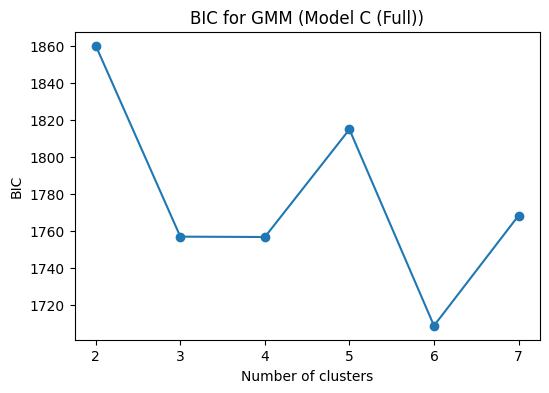

In [24]:
def bic_model(features, name="Model", data=country_df):
    X = data[features].copy()
    
    X_scaled = StandardScaler().fit_transform(X)

    bic_scores = []
    for k in range(2, 8):
        gmm = GaussianMixture(n_components=k, covariance_type="diag", random_state=42)
        gmm.fit(X_scaled)
        bic_scores.append({
            "k": k, 
            "bic": round(gmm.bic(X_scaled), 2)
        })

    bic_scores = pd.DataFrame(bic_scores)
    best_k = bic_scores['k'].loc[bic_scores['bic'].idxmin()]
    print(f"Best BIC ({name}): {bic_scores['bic'].min()} -> k={best_k}")

    plt.figure(figsize=(6,4))
    plt.plot(bic_scores["k"], bic_scores["bic"], marker="o")
    plt.title(f"BIC for GMM ({name})")
    plt.xlabel("Number of clusters")
    plt.ylabel("BIC")
    plt.show()

bic_model(model_vars_C, name="Model C (Full)")

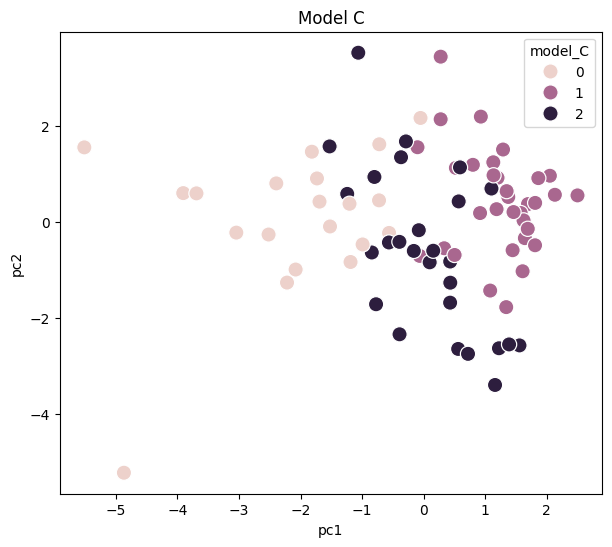

In [25]:
pca = PCA(n_components=2)
coords = pca.fit_transform(XC)

country_df["pc1"] = coords[:, 0]
country_df["pc2"] = coords[:, 1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=country_df, x="pc1", y="pc2", hue="model_C",s=120)
plt.title("Model C")
plt.show()

In [26]:
# --- Clusters' Comparison ---

def print_clusters(model):
    for c in sorted(country_df[f"model_{model}"].unique()):
        print(f"\n--- Model {model}, Cluster {c} ---")
        print(country_df[country_df[f"model_{model}"] == c]["Country"].values)

print_clusters("A")
print_clusters("B")
print_clusters("C")


--- Model A, Cluster 0 ---
['Argentina' 'Brazil' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Ecuador'
 'Estonia' 'Greece' 'Iceland' 'Jordan' 'Malaysia' 'Mexico' 'Nepal' 'Oman'
 'Panama' 'Peru' 'Republic of Korea' 'Russian Federation' 'Slovenia'
 'South Africa' 'Türkiye' 'United States of America' 'Uruguay'
 'Venezuela (Bolivarian Republic of)']

--- Model A, Cluster 1 ---
['Bangladesh' 'Benin' 'Bolivia (Plurinational State of)' 'Botswana'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Central African Republic'
 'Chad' 'Congo' "Côte d'Ivoire" 'Dominican Republic' 'Eritrea' 'Ethiopia'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Honduras' 'India' 'Indonesia'
 'Jamaica' 'Kenya' "Lao People's Democratic Republic" 'Madagascar'
 'Malawi' 'Mali' 'Mauritius' 'Mozambique' 'Namibia' 'Nicaragua' 'Niger'
 'Nigeria' 'Pakistan' 'Paraguay' 'Philippines' 'Rwanda' 'Senegal'
 'Sierra Leone' 'Sri Lanka' 'Thailand' 'Togo'
 'United Republic of Tanzania' 'Viet Nam' 'Zambia']

--- Model A, Cluster 2 ---
['Ant

In [27]:
def country_to_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

country_df["iso3"] = country_df["Country"].apply(country_to_iso3)

In [28]:
country_df[country_df["iso3"].isna()][["Country"]]

,Country
6,Bolivia (Plurinational State of)
59,Republic of Korea
77,Venezuela (Bolivarian Republic of)


In [29]:
manual_iso = {
    "Bolivia (Plurinational State of)": "BOL",
    "Republic of Korea": "KOR",
    "Venezuela (Bolivarian Republic of)": "VEN",
}

In [30]:
country_df["iso3"] = country_df["iso3"].fillna(
    country_df["Country"].map(manual_iso)
)

In [31]:
for model in ["A","B","C"]:
    temp = country_df.copy()
    temp[f"model_{model}"] = temp[f"model_{model}"].astype(str)

    fig = px.choropleth(temp, locations="iso3", color=f"model_{model}", hover_name="Country",
                        color_discrete_sequence=px.colors.qualitative.Set2, 
                        projection="natural earth", title=f"Country Clusters (Model {model})")
    fig.show()

In [32]:
def cluster_summary(model):
    return country_df.groupby(f"model_{model}")[[
       'log_rd_mean', 'gdp_per_capita_mean', 'log_population_mean',
       'rural_pop_pct_mean', 'rural_land_pct_mean', 'temperature_mean',
       'rd_trend', 'gdp_trend', 'production_cv'
    ]].mean()

In [33]:
cluster_summary("C")

,log_rd_mean,gdp_per_capita_mean,log_population_mean,rural_pop_pct_mean,rural_land_pct_mean,temperature_mean,rd_trend,gdp_trend,production_cv
model_C,,,,,,,,,
0,5.001968,16356.200169,16.707683,24.273871,34.270939,15.064776,0.035849,176.563214,0.095178
1,3.469131,1014.700920,16.718545,64.837637,47.866016,25.560505,0.009139,42.027405,0.191701
2,3.354844,7838.657935,15.168450,47.657919,32.136744,25.141465,0.006415,251.043115,0.119325


**Cluster Interpretation (Model C):**

**1. Cluster 0 - High-income, high R&D, stable economies:**
- Very high agricultural R&D investments (5).
- High GDP per capita (16356).
- High population scale.
- Low rural population share (~24%).
- Moderate agricultural land dependence.
- Low temperatures (~15C).
- Lower agricultural volatility (low Production CV ~0.09).
- Fastest growth in R&D investments (~3.5% annually).
- Steady economic growth (GDP per capita increases by ~$176 annually).

**2. Cluster 1 - Low-income, high rural dependence, high instable economies:**
- Moderate R&D investment (3.46).
- Very Low GDP per capita (1014).
- Very high rural population share (~65%).
- High agricultural land dependence.
- High temperatures (~25-26C).
- Highest production volatility (CV ~0.19).
- Low R&D investments (minimal growth of ~0.9% annually).
- Slowest economic improvement (GDP per capita increases by only ~$42 annually).

**3. Cluster 2 - Mixed economies, heterogeneous structure:**
- The lowest R&D investment (3.35).
- Medium GDP (7838).
- The lowest population size compared to Cluster 0, 1.
- Medium rural population share (~48%).
- The lowest agricultural land proportion.
- Higher temperatures than Cluster 0 but lower than Cluster 1 (~25C).
- Moderate volatility (CV ~0.11).
- The lowest growth in agricultural R&D investments (~0.6% annually).
- Fastest overall economic growth (GDP per capita increases by ~$251 annually).

## Causal Forest

ОбчислюЄмо індивідуальну пользу від інвестицій для кожної країни

Causal Forest очищає дані від побічних факторів (клімату, багатства) і доводиш, що інвестиції в R&D справді мають причинно-наслідковий вплив на виробництво, і цей вплив кардинально різний для різних кластерів
Доводить гіпотезу H2.

**Hypothesis H2:** The magnitude and timing of agricultural R&D effects differ across country clusters.

In [34]:
Y = country_df['log_production_mean'] # Outcome
T = country_df['log_rd_mean']         # Treatment

"""
наскільки змінюється expected production, якщо “перейти” від lower R&D до higher R&D, 
при однакових X
"""

# X (Confounders)
X_features = [
    'gdp_per_capita_mean', 
    'log_population_mean',
    'rural_pop_pct_mean', 
    'rural_land_pct_mean', 
    'temperature_mean' 
]
X = country_df[X_features]

In [35]:
causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, random_state=42), # type: ignore
    model_t=RandomForestRegressor(n_estimators=100, random_state=42), # type: ignore # type: ignore
    criterion='mse',
    n_estimators=500,       
    min_samples_leaf=5,     
    random_state=42
)
causal_forest.fit(Y, T, X=X)

In [36]:
country_df.groupby("model_C")["log_rd_mean"].describe()

,count,mean,std,min,25%,50%,75%,max
model_C,,,,,,,,
0,20.0,5.001968,1.455394,3.125436,4.073609,4.556060,6.289612,8.555404
1,33.0,3.469131,1.587163,0.197563,2.479876,3.213722,4.314139,7.988623
2,27.0,3.354844,2.355371,0.165489,1.246241,3.141614,4.882120,8.328248


In [37]:
country_df['treatment_effect'] = causal_forest.effect(X)
country_df.groupby("model_C")["treatment_effect"].std()

model_C
0    0.106387
1    0.127720
2    0.097716
Name: treatment_effect, dtype: float64

In [38]:
print("Average Treatment Effect by Cluster (Model C):")
te_summary = country_df.groupby("model_C")["treatment_effect"].mean().reset_index()
te_summary

Average Treatment Effect by Cluster (Model C):


,model_C,treatment_effect
0,0,0.290732
1,1,0.172990
2,2,0.169796


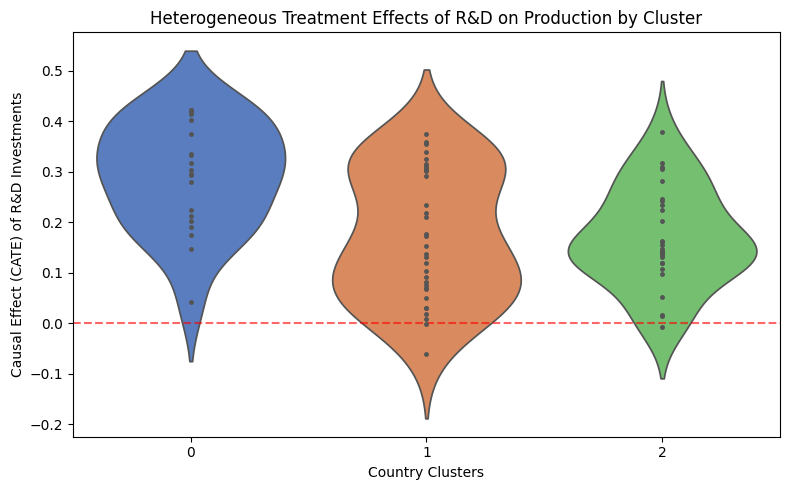

In [39]:
plt.figure(figsize=(8, 5))

sns.violinplot(data=country_df, x='model_C', y='treatment_effect', palette='muted', inner='point' )
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.title("Heterogeneous Treatment Effects of R&D on Production by Cluster")
plt.xlabel("Country Clusters")
plt.ylabel("Causal Effect (CATE) of R&D Investments")
plt.tight_layout()
plt.show()

In [40]:
top_performers = country_df[
    ['Country', 'model_C', 'treatment_effect']
].sort_values(by='treatment_effect', ascending=False)
top_performers.head()

,Country,model_C,treatment_effect
68,South Africa,0,0.423307
46,Mexico,0,0.421941
73,Türkiye,0,0.419148
75,United States of America,0,0.413919
1,Argentina,0,0.403797


The results indicate substantial heterogeneity in the relationship between R&D intensity and agricultural productivity across country clusters.

Countries in **Cluster 0** exhibit the strongest association, where higher R&D intensity is linked to significantly higher productivity levels.

In contrast, **Clusters 1** and **Cluster 2** show considerably weaker effects, suggesting diminishing responsiveness of productivity to R&D in these regimes.

## Cluster-specific Lag Analysis

**Hypothesis H3:** The causal effect of agricultural R&D investments is heterogeneous across country clusters.

In [41]:
df = df.drop( 
    columns=[c for c in df.columns if "model_C" in c], 
    errors="ignore" 
) 

df = df.merge(
    country_df[["Country", "model_C"]], 
    on="Country", 
    how="left"
)

In [42]:
df = df.sort_values(["Country", "year"]).copy()

lags = [1, 2, 3, 4, 5]

for l in lags:
    df[f"lag_{l}"] = df.groupby("Country")["log_rd"].shift(l)

In [43]:
controls = [
    "gdp_per_capita",
    "rural_pop_pct",
    "rural_land_pct",
    "temperature",
    "log_population"
]

lag_cols = [f"lag_{l}" for l in lags]

df_lag = df.dropna(
    subset=["log_production", "model_C"] + lag_cols + controls
).copy()

In [44]:
df_lag[[f"lag_{i}" for i in range(1,6)]].corr()

,lag_1,lag_2,lag_3,lag_4,lag_5
lag_1,1.000000,0.996547,0.993700,0.991677,0.989739
lag_2,0.996547,1.000000,0.996694,0.994160,0.992104
lag_3,0.993700,0.996694,1.000000,0.997055,0.994417
lag_4,0.991677,0.994160,0.997055,1.000000,0.997097
lag_5,0.989739,0.992104,0.994417,0.997097,1.000000


Due to the extremely high correlation among individual lagged R&D variables (all pairwise correlations above 0.98), estimating precise lag-specific effects is statistically challenging. Therefore, lagged investments were additionally grouped into short-, medium-, and long-term horizons to identify broader investment response periods.

In [45]:
# ---- window lags ----

df["short_term"] = df[["lag_1", "lag_2"]].mean(axis=1)
df["medium_term"] = df[["lag_3", "lag_4"]].mean(axis=1)
df["long_term"] = df["lag_5"]

In [46]:
window_cols = ["short_term", "medium_term", "long_term"]

df_win = df.dropna(
    subset=["log_production", "model_C", "year"] + controls + window_cols
).copy()

In [47]:
results_window = []

for cluster in sorted(df_win["model_C"].dropna().unique()):

    sub = df_win[df_win["model_C"] == cluster].copy()

    if sub["Country"].nunique() < 2 or len(sub) < 30:
        print(f"Skipping cluster {cluster} (not enough data)")
        continue

    model = smf.ols(
        f"""
        log_production ~
        short_term +
        medium_term +
        long_term +
        {' + '.join(controls)}
        + C(Country)
        + C(year)
        """,
        data=sub
    ).fit(
  
        cov_type="cluster",
        cov_kwds={"groups": sub["Country"]}
    )   

    results_window.append({
        "cluster": cluster,
        "short_coef": model.params.get("short_term", np.nan),
        "short_p": model.pvalues.get("short_term", np.nan),
        "medium_coef": model.params.get("medium_term", np.nan),
        "medium_p": model.pvalues.get("medium_term", np.nan),
        "long_coef": model.params.get("long_term", np.nan),
        "long_p": model.pvalues.get("long_term", np.nan),
    })

window_df = pd.DataFrame(results_window)
window_df

,cluster,short_coef,short_p,medium_coef,medium_p,long_coef,long_p
0,0.0,-0.016007,0.530534,0.033447,0.566779,-0.104891,0.055906
1,1.0,0.032605,0.561070,0.036571,0.603241,0.016169,0.793186
2,2.0,0.028684,0.736452,0.030283,0.739679,0.047452,0.458471


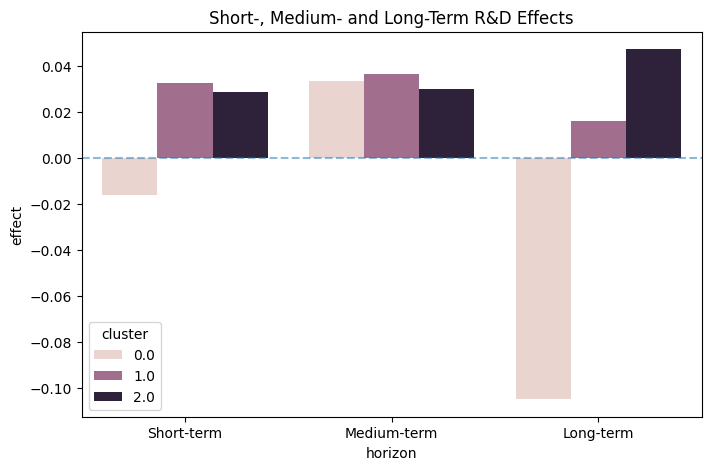

In [48]:
plot_df = window_df.melt(
    id_vars="cluster",
    value_vars=["short_coef","medium_coef","long_coef"],
    var_name="horizon",
    value_name="effect"
)

plot_df["horizon"] = plot_df["horizon"].replace({
    "short_coef": "Short-term",
    "medium_coef": "Medium-term",
    "long_coef": "Long-term"
})

plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x="horizon", y="effect", hue="cluster")
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Short-, Medium- and Long-Term R&D Effects")
plt.show()

## Cluster-specific Investment Strategy Classification

**The strategy profile summarizes each cluster using four indicators:**
1. The average Causal Magnitude Treatment Effect (CMc) 
2. Dominant response horizon (Tc)
3. Maximum estimated R&D response coefficient (βmax)
4. Production stability (CVc)
5. Statistical consistency of estimated effects (SCc)

In [49]:
strategy_df = window_df.copy()

In [50]:
# 1. Maximum estimated response coefficient (βmax)
def positive_max(row):
    coefficients = row[["short_coef", "medium_coef", "long_coef"]]

    positive_coefficients = coefficients[coefficients > 0]
    if len(positive_coefficients) == 0:
        return np.nan
    
    return positive_coefficients.max()

strategy_df["beta_max"] = strategy_df.apply(
    positive_max,
    axis=1
)
strategy_df[["cluster", "beta_max"]]

,cluster,beta_max
0,0.0,0.033447
1,1.0,0.036571
2,2.0,0.047452


In [51]:
# 2. Classify response magnitude using quartile thresholds

beta_q25 = strategy_df["beta_max"].quantile(0.25)
beta_q75 = strategy_df["beta_max"].quantile(0.75)

print(f"25th percentile: {beta_q25:.4f}")
print(f"75th percentile: {beta_q75:.4f}")

def classify_beta(x):
    if x > beta_q75:
        return "High response"
    elif x < beta_q25:
        return "Low response"
    else:
        return "Moderate response"


strategy_df["beta_class"] = strategy_df["beta_max"].apply(classify_beta)
strategy_df[["cluster", "beta_max", "beta_class"]]

25th percentile: 0.0350
75th percentile: 0.0420


,cluster,beta_max,beta_class
0,0.0,0.033447,Low response
1,1.0,0.036571,Moderate response
2,2.0,0.047452,High response


In [52]:
# 3. Production stability (CVc)

cluster_cv = (
    country_df
    .groupby("model_C")["production_cv"]
    .mean()
)

cv_median = cluster_cv.median()
print(f"Median cluster CV: {cv_median:.4f}")

def classify_cv(x):
    if x > cv_median:
        return "High volatility"
    else:
        return "Stable production"

cluster_cv_profile = cluster_cv.apply(classify_cv)
cluster_cv_profile

Median cluster CV: 0.1193


model_C
0    Stable production
1      High volatility
2    Stable production
Name: production_cv, dtype: object

In [53]:
# 4. Statistical consistency of R&D effects (SCc)

p_values = [
    "short_p",
    "medium_p",
    "long_p"
]

strategy_df["SCc"] = (
    strategy_df[p_values]
    .lt(0.05)
    .mean(axis=1)
)

strategy_df[["cluster", "SCc"]]

,cluster,SCc
0,0.0,0.0
1,1.0,0.0
2,2.0,0.0


In [54]:
# 5. Dominant response horizon (Tc)

horizon_columns = {
    "short_coef": "Short-term",
    "medium_coef": "Medium-term",
    "long_coef": "Long-term"
}


def identify_horizon(row):
    effects = {
        horizon: row[column]
        for column, horizon in horizon_columns.items()
    }

    positive_effects = {
        h: value
        for h, value in effects.items()
        if value > 0
    }

    if not positive_effects:
        return "No positive response"

    return max(positive_effects, key=positive_effects.get) # type: ignore


strategy_df["Tc"] = strategy_df.apply(
    identify_horizon,
    axis=1
)
strategy_df[["cluster", "Tc"]]

,cluster,Tc
0,0.0,Medium-term
1,1.0,Medium-term
2,2.0,Long-term


In [55]:
# 6. Final strategy profile table
final_strategy = (
    strategy_df[["cluster","Tc","beta_max","beta_class","SCc"]].merge(
        cluster_cv.rename("CVc"),
        left_on="cluster",
        right_index=True
    )
)
final_strategy

,cluster,Tc,beta_max,beta_class,SCc,CVc
0,0.0,Medium-term,0.033447,Low response,0.0,0.095178
1,1.0,Medium-term,0.036571,Moderate response,0.0,0.191701
2,2.0,Long-term,0.047452,High response,0.0,0.119325


In [56]:
causal_effect = country_df.groupby("model_C")["treatment_effect"].mean().rename("CMc")
# Causal_Magnitude
final_strategy = (
    strategy_df[["cluster","Tc","beta_max","beta_class","SCc"]].merge(
        cluster_cv.rename("CVc"),
        left_on="cluster",
        right_index=True
    ).merge(
        causal_effect, 
        left_on="cluster",
        right_index=True
    )
)

final_strategy

,cluster,Tc,beta_max,beta_class,SCc,CVc,CMc
0,0.0,Medium-term,0.033447,Low response,0.0,0.095178,0.290732
1,1.0,Medium-term,0.036571,Moderate response,0.0,0.191701,0.172990
2,2.0,Long-term,0.047452,High response,0.0,0.119325,0.169796


## Hypotheses Evaluation

**H1: Countries can be classified into distinct clusters based on economic, demographic and environmental characteristics.**

*The hypothesis is supported.*

The clustering results demonstrated that countries can be grouped according to their economic, demographic, and environmental characteristics, identifying three distinct country groups. These clusters exhibited substantial differences in agricultural R&D investment levels, production stability. GDP per capita, rural population share, and environmental conditions. 
 
**H2: The magnitude and timing of agricultural R&D effects differ across country clusters.**

*The hypothesis is supported.*

The causal forest results show that the effect of agricultural R&D on productivity differs across country clusters and depends on their structural characteristics. 

**H3: The causal effect of agricultural R&D investments is heterogeneous across country clusters.**

*The hypothesis is partially supported.*
 
The estimated investment horizons differed across country clusters, suggesting variation in the timing of R&D effects. However, the lag coefficients are not statistically significant. Therefore, the evidence of temporal heterogeneity should be interpreted as suggestive rather than conclusive.
